In [5]:
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import random
import numpy as np

zip_path = '/content/fruits.zip'
extract_path = '/content/fruit_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/fruit_data


## Preparation : Parsing & Visualization

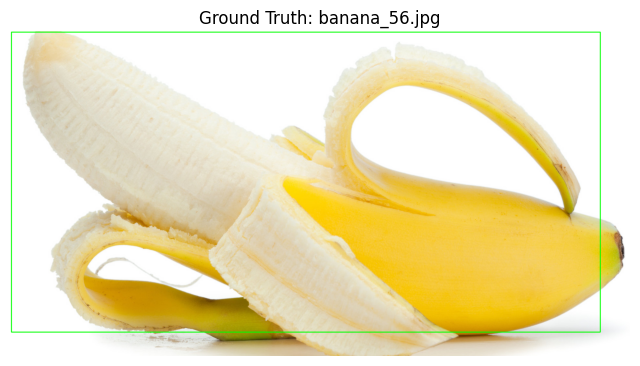

In [9]:
def parse_xml(xml_path):
    """Parses the XML file to extract bounding boxes and labels."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall('object'):
        label = obj.find('name').text
        bndbox = obj.find('bndbox')

        # Extracting coordinates as integers
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

def visualize_ground_truth(image_dir):
    """Loads a random image and its annotation to visualize ground truth."""
    # Get all image files (filtering for .jpg)
    all_images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    random_image_name = random.choice(all_images)

    # Define paths
    img_path = os.path.join(image_dir, random_image_name)
    xml_path = os.path.join(image_dir, random_image_name.replace('.jpg', '.xml'))

    # Load Image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Parse Annotations
    boxes, labels = parse_xml(xml_path)

    # Plotting
    plt.figure(figsize=(8, 8))
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        # Draw rectangle
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        # Put Label Text
        cv2.putText(image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.imshow(image)
    plt.title(f"Ground Truth: {random_image_name}")
    plt.axis('off')
    plt.show()

# Run the visualization for the training set
train_dir = '/content/fruit_data/fruits/train'
visualize_ground_truth(train_dir)

## Task 1: Intersection over Union (IoU)

In [8]:
def calculate_iou(boxA, boxB):
    """
    Calculates the Intersection over Union (IoU) of two bounding boxes.
    Input format: [x_min, y_min, x_max, y_max]
    """
    # Determine the coordinates of the intersection rectangle
    x_inter_min = max(boxA[0], boxB[0])
    y_inter_min = max(boxA[1], boxB[1])
    x_inter_max = min(boxA[2], boxB[2])
    y_inter_max = min(boxA[3], boxB[3])

    # area of intersection
    inter_width = max(0, x_inter_max - x_inter_min)
    inter_height = max(0, y_inter_max - y_inter_min)
    inter_area = inter_width * inter_height

    # area of both individual bounding boxes
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # area of the union (Area A + Area B - Intersection)
    union_area = float(areaA + areaB - inter_area)

    # IoU score
    iou = inter_area / union_area if union_area > 0 else 0.0
    return iou

print("--- Task 1: IoU Demonstration ---")

# 1. Highly overlapping pair
box1 = [50, 50, 150, 150]
box2 = [60, 60, 140, 140]
print(f"Highly Overlapping Pair IoU: {calculate_iou(box1, box2):.4f}")

# 2. Partially overlapping pair
box3 = [50, 50, 150, 150]
box4 = [100, 100, 200, 200]
print(f"Partially Overlapping Pair IoU: {calculate_iou(box3, box4):.4f}")

# 3. Completely disjoint pair
box5 = [0, 0, 50, 50]
box6 = [100, 100, 150, 150]
print(f"Completely Disjoint Pair IoU: {calculate_iou(box5, box6):.4f}")

--- Task 1: IoU Demonstration ---
Highly Overlapping Pair IoU: 0.6400
Partially Overlapping Pair IoU: 0.1429
Completely Disjoint Pair IoU: 0.0000


## Task 2: The Baseline - Selective Search (R-CNN)

Running Selective Search... 


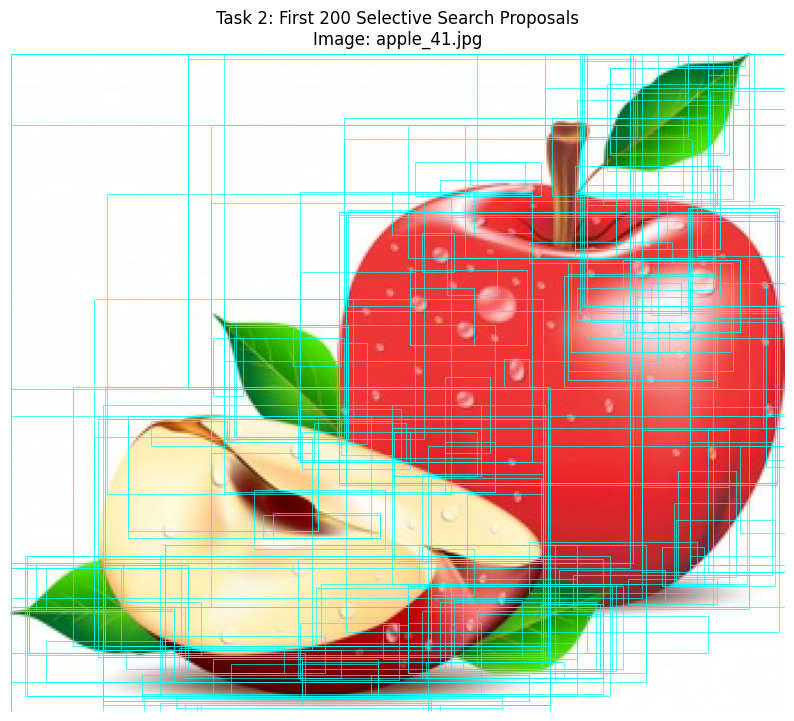

Total proposals found: 200


In [22]:
import cv2
import matplotlib.pyplot as plt
import os
import random

# Note: Selective Search is part of the opencv-contrib-python package
def run_selective_search(image_path):

    image = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image)

    ss.switchToSelectiveSearchFast()

    print("Running Selective Search... ")
    rects = ss.process()

    # the first 200 region proposals
    # format: [x, y, w, h]
    top_200_proposals = rects[:200]

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)

    for i, rect in enumerate(top_200_proposals):
        x, y, w, h = rect
        rect_patch = plt.Rectangle((x, y), w, h, fill=False, edgecolor='cyan', linewidth=0.5)
        plt.gca().add_patch(rect_patch)

    plt.title(f"Task 2: First 200 Selective Search Proposals\nImage: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()

    return top_200_proposals, image

all_images = [f for f in os.listdir(train_dir) if f.endswith('.jpg')]
random_img_path = os.path.join(train_dir, random.choice(all_images))

proposals, original_image = run_selective_search(random_img_path)
print(f"Total proposals found: {len(proposals)}")

## Task 3: Implementing the R-CNN Bottleneck

In [23]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import time
from PIL import Image

# Loadred pre-trained ResNet18 and remove the final FC layer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet18 = models.resnet18(weights='IMAGENET1K_V1').to(device)
resnet18.fc = torch.nn.Identity()  # Removing final layer so it outputs feature vectors
resnet18.eval()

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

top_100_boxes = proposals[:100]
feature_vectors = []

start_time = time.time()

print(f"Processing 100 crops individually on {device}...")

with torch.no_grad():
    for box in top_100_boxes:
        x, y, w, h = box
        if w <= 0 or h <= 0:
            continue

        crop = original_image[y:y+h, x:x+w]

        crop_tensor = preprocess(crop).unsqueeze(0).to(device)

        features = resnet18(crop_tensor)
        feature_vectors.append(features)

end_time = time.time()
task_3_duration = end_time - start_time

print("-" * 60)
print(f"Task 3 Execution Time: {task_3_duration:.4f} seconds")
print(f"Number of feature vectors extracted: {len(feature_vectors)}")
print("-" * 60)

Processing 100 crops individually on cuda...
------------------------------------------------------------
Task 3 Execution Time: 0.3981 seconds
Number of feature vectors extracted: 100
------------------------------------------------------------


## Task 4: Implementing Fast R-CNN (RoI Pooling)

### Implementation and Timing

In [24]:
import torch
import torchvision.ops as ops
import time

# The feature extractor (all layers except the final pooling and FC)
feature_extractor = torch.nn.Sequential(*list(resnet18.children())[:-2])
feature_extractor.eval()

# Passing the entire image through the CNN once
input_image = cv2.resize(original_image, (224, 224))
img_tensor = preprocess(input_image).unsqueeze(0).to(device)

start_time_fast = time.time()

with torch.no_grad():
    feature_map = feature_extractor(img_tensor) # Single CNN pass [cite: 35]

# Spatial Scale
# Original image 224x224 -> Feature map 7x7. Scale = 7/224 = 1/32
spatial_scale = 1/32

# Preparing bounding boxes for roi_pool
# Format: [batch_index, x1, y1, x2, y2]
h_orig, w_orig = original_image.shape[:2]
rois_list = []
for box in top_100_boxes:
    x, y, w, h = box
    x1 = (x / w_orig) * 224
    y1 = (y / h_orig) * 224
    x2 = ((x + w) / w_orig) * 224
    y2 = ((y + h) / h_orig) * 224
    rois_list.append([0, x1, y1, x2, y2])

rois_tensor = torch.tensor(rois_list, dtype=torch.float).to(device)

# RoI Pooling
pooled_features = ops.roi_pool(feature_map, rois_tensor, output_size=(7, 7), spatial_scale=spatial_scale)

end_time_fast = time.time()
task_4_duration = end_time_fast - start_time_fast

print("-" * 60)
print(f"Task 4 Execution Time (Fast R-CNN): {task_4_duration:.4f} seconds")
print(f"Task 3 Execution Time (R-CNN):      {task_3_duration:.4f} seconds")
print(f"Speedup Factor: {task_3_duration / task_4_duration:.2f}x")
print("-" * 60)

------------------------------------------------------------
Task 4 Execution Time (Fast R-CNN): 0.0045 seconds
Task 3 Execution Time (R-CNN):      0.3981 seconds
Speedup Factor: 87.86x
------------------------------------------------------------


### Conceptual Analysis

**Question:**<br> What redundant mathematical operations does Fast R-CNN eliminate to achieve this efficiency?

**Answer:**<br>
Fast R-CNN eliminates the redundant convolutional computations performed on overlapping regions of an image.


- R-CNN Redundancy: In the R-CNN approach (Task 3), if two region proposals overlap by 90%, the CNN independently processes the pixels in that overlapping area twice. Across 200 proposals, the same pixels are convolved hundreds of times.


- Fast R-CNN Efficiency: By passing the image through the backbone only once, the feature map is computed once for the entire scene. RoI Pooling then simply "crops" the already-computed features, replacing expensive deep-layer convolutions with a simple max-pooling operation on the existing feature map.

## Task 5: Implementing Faster R-CNN

### Implementation

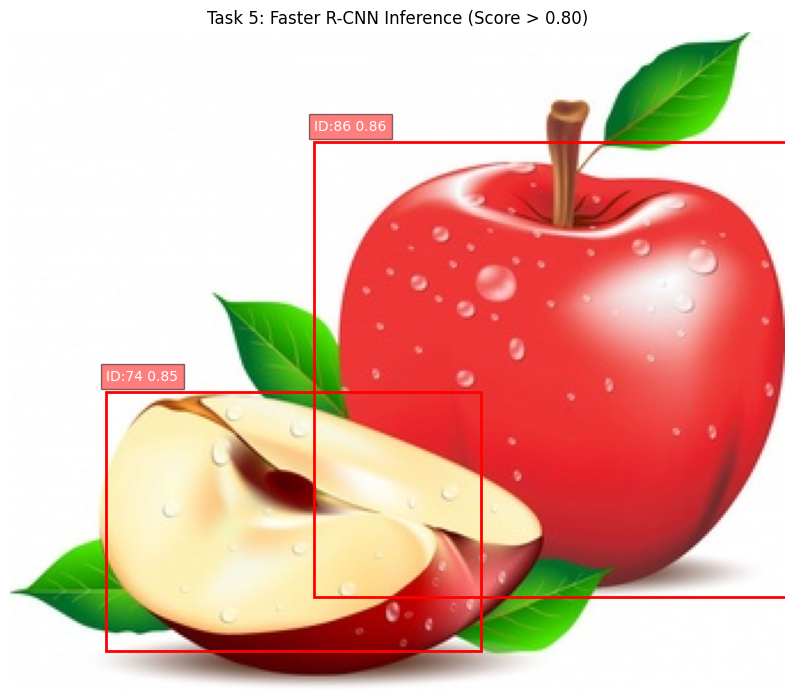

Detected 2 objects with confidence > 0.80


In [25]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import numpy as np

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device)
model.eval()

img_tensor_faster = transforms.ToTensor()(original_image).unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(img_tensor_faster)[0]

def filter_predictions(prediction, threshold=0.80):
    """Filters out predictions below the specified confidence score."""
    scores = prediction['scores']
    mask = scores > threshold

    filtered_boxes = prediction['boxes'][mask].cpu().numpy()
    filtered_labels = prediction['labels'][mask].cpu().numpy()
    filtered_scores = scores[mask].cpu().numpy()

    return filtered_boxes, filtered_labels, filtered_scores

boxes, labels, scores = filter_predictions(prediction)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
ax = plt.gca()

for box, label, score in zip(boxes, labels, scores):
    xmin, ymin, xmax, ymax = box
    width, height = xmax - xmin, ymax - ymin

    rect = plt.Rectangle((xmin, ymin), width, height, fill=False, color='red', linewidth=2)
    ax.add_patch(rect)

    plt.text(xmin, ymin - 5, f"ID:{label} {score:.2f}", color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.5))

plt.title("Task 5: Faster R-CNN Inference (Score > 0.80)")
plt.axis('off')
plt.show()

print(f"Detected {len(boxes)} objects with confidence > 0.80")

### Conceptual Analysis

**Question:**<br> How does the RPN eliminate the need for external algorithms like Selective Search?

**Answer:**<br>
The Region Proposal Network (RPN) eliminates external algorithms by integrating the proposal generation step directly into the neural network architecture.

- Shared Features: RPN shares the same convolutional feature maps used by the detection head, meaning it doesn't need to re-scan the image from scratch.

- Anchor Boxes: It uses "anchors" (fixed-sized reference boxes) across the feature map to predict objectness scores and bounding box regressions simultaneously.

- GPU Acceleration: Unlike Selective Search, which is a CPU-bound grouping algorithm based on hand-crafted heuristics, RPN is fully differentiable and runs on the GPU, making the entire detection pipeline significantly faster.

## Task 6: Non-Maximum Suppression (NMS)

### Implementation

In [26]:
def nms_custom(boxes, scores, iou_threshold):
    """
    Custom NMS implementation.
    - boxes: List or tensor of [x1, y1, x2, y2]
    - scores: List or tensor of confidence scores
    - iou_threshold: Float threshold for discarding overlapping boxes
    """
    if len(boxes) == 0:
        return []

    # Sorting the boxes by confidence score in descending order
    indices = np.argsort(scores)[::-1]
    keep_indices = []

    while len(indices) > 0:
        # Selecting the box with the highest score
        current_idx = indices[0]
        keep_indices.append(current_idx)

        if len(indices) == 1:
            break

        remaining_indices = indices[1:]
        filtered_indices = []

        # Comparing selected box to all remaining boxes
        for idx in remaining_indices:
            iou = calculate_iou(boxes[current_idx], boxes[idx])

            # Discarding boxes with IoU greater than the threshold
            if iou <= iou_threshold:
                filtered_indices.append(idx)

        # Repeating process for the next highest-scoring box
        indices = np.array(filtered_indices)

    return keep_indices

# Simulated overlapping boxes for an apple
test_boxes = [
    [50, 50, 150, 150],  # Box A (Highest score)
    [55, 55, 155, 155],  # Box B (Heavy overlap with A)
    [200, 200, 300, 300] # Box C (Distinct object)
]
test_scores = [0.95, 0.92, 0.88]
threshold = 0.5

keep = nms_custom(np.array(test_boxes), np.array(test_scores), threshold)

print(f"Indices kept: {keep}")
print(f"Final Bounding Boxes: {[test_boxes[i] for i in keep]}")

Indices kept: [np.int64(0), np.int64(2)]
Final Bounding Boxes: [[50, 50, 150, 150], [200, 200, 300, 300]]


### Conceptual Analysis

**Question:** <br> If you are trying to detect a cluster of tightly packed objects (e.g., several apples piled together in a basket), how would setting the IoU threshold extremely high (0.9) versus extremely low (0.1) alter your final visual predictions? Explain why.

**Answer:**<br>
- Extremely High IoU Threshold (0.9): This makes the NMS algorithm very permissive. It will only discard a box if it overlaps with a higher-scoring box by more than 90%. In a basket of piled apples, this would likely result in multiple redundant boxes for the same apple being displayed, making the output look cluttered. However, it ensures that distinct, tightly packed apples are not accidentally deleted.

- Extremely Low IoU Threshold (0.1): This makes the algorithm very aggressive. Even a slight overlap (10%) will cause the lower-scoring box to be discarded. In a cluster of apples, where objects naturally overlap, this would result in under-detection. The algorithm would likely keep one apple's box and delete the boxes of all neighboring apples, treating them as "duplicates" of the first one.

 For tightly packed objects, a moderate threshold (like 0.45 to 0.6) is necessary to balance the removal of duplicate predictions against the preservation of distinct object instances.

## Task 7: YOLO Fine-Tuning

In [32]:
!pip install ultralytics -q
from ultralytics import YOLO
import yaml

### Dataset Preperation

In [31]:
import cv2
import xml.etree.ElementTree as ET
import yaml

# Define classes based on dataset scope
classes = ['apple', 'banana', 'orange']

def convert_to_yolo(folder_path):
    """Converts Pascal VOC XML files to YOLO .txt format"""
    print(f"Processing folder: {folder_path}")
    count = 0
    skipped = 0

    for file in os.listdir(folder_path):
        if not file.endswith('.xml'):
            continue

        xml_path = os.path.join(folder_path, file)
        img_path = xml_path.replace('.xml', '.jpg')

        tree = ET.parse(xml_path)
        root = tree.getroot()

        width = int(root.find('size/width').text)
        height = int(root.find('size/height').text)

        if width == 0 or height == 0:
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    height, width, _ = img.shape
                else:
                    print(f"Error: Could not read image {img_path}")
                    skipped += 1
                    continue
            else:
                print(f"Error: Image file not found for {file}")
                skipped += 1
                continue

        yolo_data = []
        for obj in root.findall('object'):
            label = obj.find('name').text.lower()
            if label not in classes:
                continue

            class_id = classes.index(label)
            bbox = obj.find('bndbox')

            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)

            # Normalize coordinates using the width and height
            x_center = ((xmin + xmax) / 2) / width
            y_center = ((ymin + ymax) / 2) / height
            w = (xmax - xmin) / width
            h = (ymax - ymin) / height

            yolo_data.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        with open(xml_path.replace('.xml', '.txt'), 'w') as f:
            f.write('\n'.join(yolo_data))

        count += 1

    print(f"Finished: Processed {count} files, Skipped {skipped} files.")

convert_to_yolo('/content/fruit_data/fruits/train')
convert_to_yolo('/content/fruit_data/fruits/test')

# Create the data.yaml file required for YOLO training
data_yaml = {
    'train': '/content/fruit_data/fruits/train',
    'val': '/content/fruit_data/fruits/test',
    'nc': 3,
    'names': classes
}

with open('fruit_data.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

Processing folder: /content/fruit_data/fruits/train
Finished: Processed 240 files, Skipped 0 files.
Processing folder: /content/fruit_data/fruits/test
Finished: Processed 60 files, Skipped 0 files.


### Training (Fine-tuning)

In [46]:
model_yolo = YOLO('yolov8n.pt')

results = model_yolo.train(data='fruit_data.yaml', epochs=10, imgsz=300, plots=True)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fruit_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=300, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

### Inference and Visualization

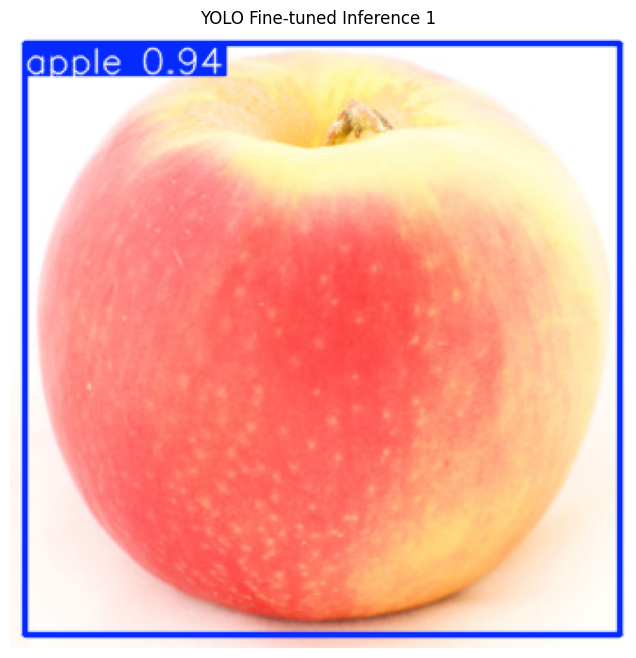

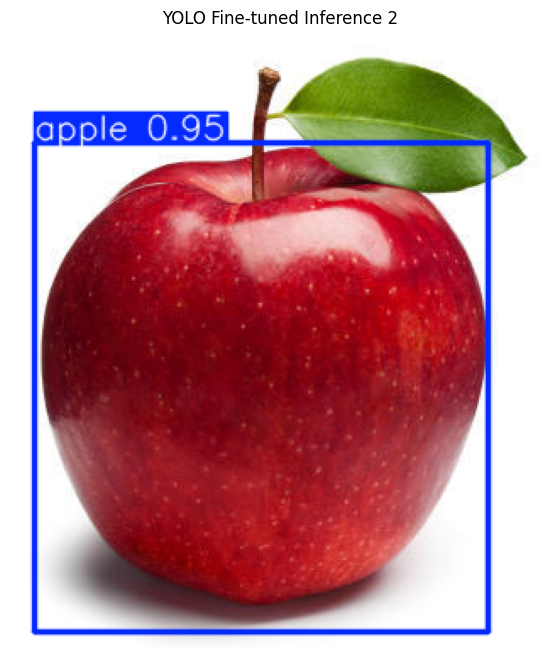

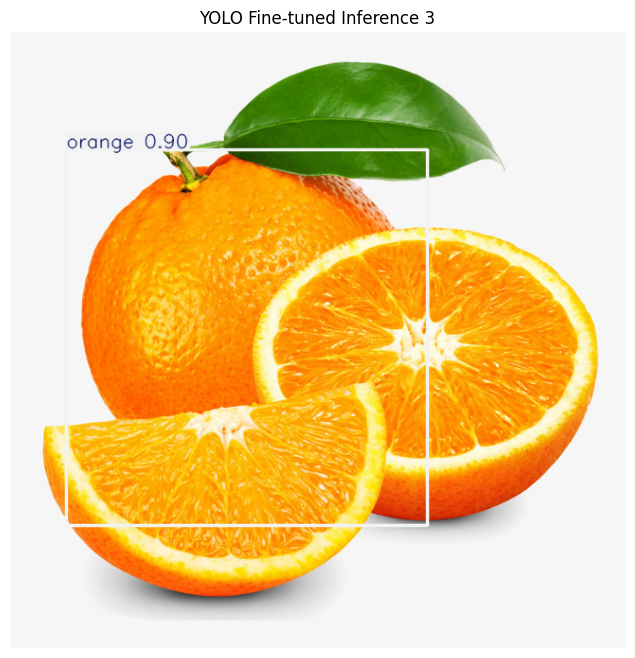

In [56]:
import glob

test_images = glob.glob('/content/fruit_data/fruits/test/*.jpg')[:3]
results_inf = model_yolo.predict(source=test_images, conf=0.5)

for i, r in enumerate(results_inf):
    im_array = r.plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.title(f"YOLO Fine-tuned Inference {i+1}")
    plt.axis('off')
    plt.show()

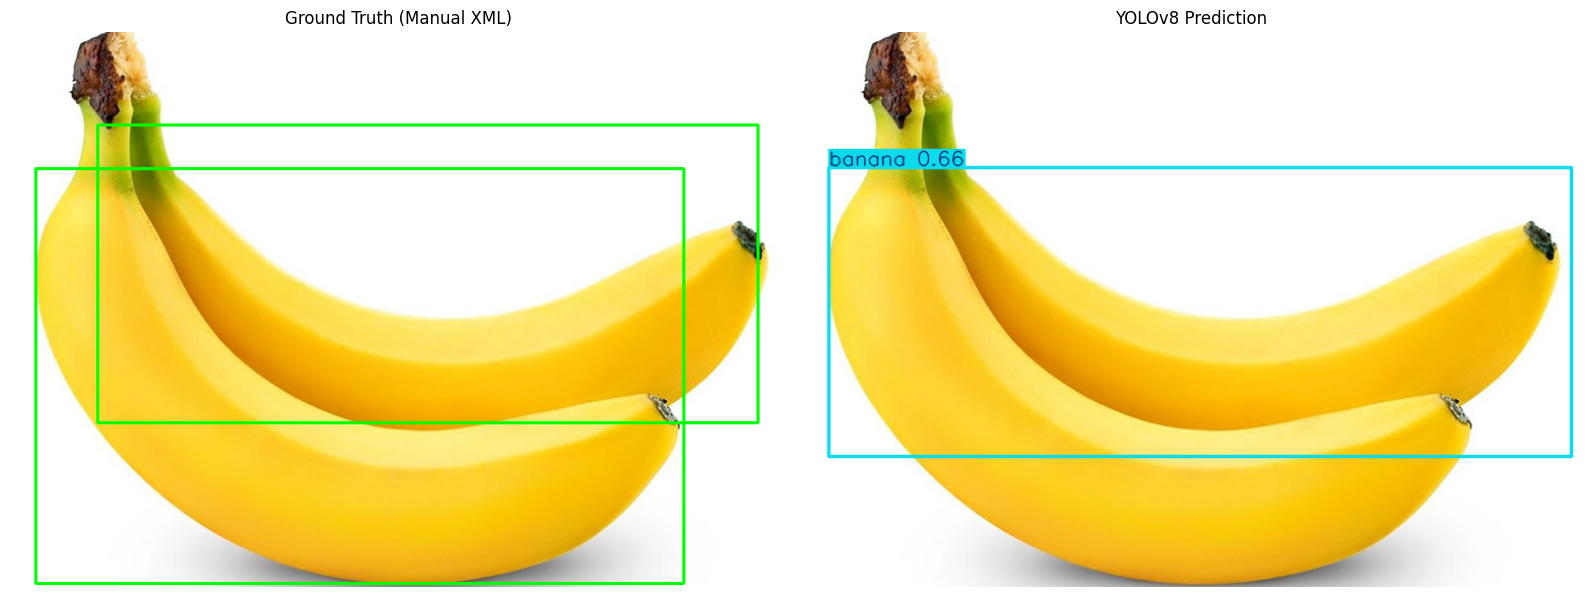

In [62]:
test_images = glob.glob('/content/fruit_data/fruits/test/*.jpg')
random_test_img = random.choice(test_images)
random_test_xml = random_test_img.replace('.jpg', '.xml')

gt_boxes, gt_labels = parse_xml(random_test_xml)
img_gt = cv2.imread(random_test_img)
img_gt = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)
for box, label in zip(gt_boxes, gt_labels):
    cv2.rectangle(img_gt, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

results = model_yolo.predict(random_test_img, conf=0.5, verbose=False)[0]
img_pred = results.plot()
img_pred = cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(img_gt)
ax[0].set_title("Ground Truth (Manual XML)")
ax[0].axis('off')

ax[1].imshow(img_pred)
ax[1].set_title("YOLOv8 Prediction")
ax[1].axis('off')

plt.tight_layout()
plt.savefig('gt_vs_pred.png')
plt.show()

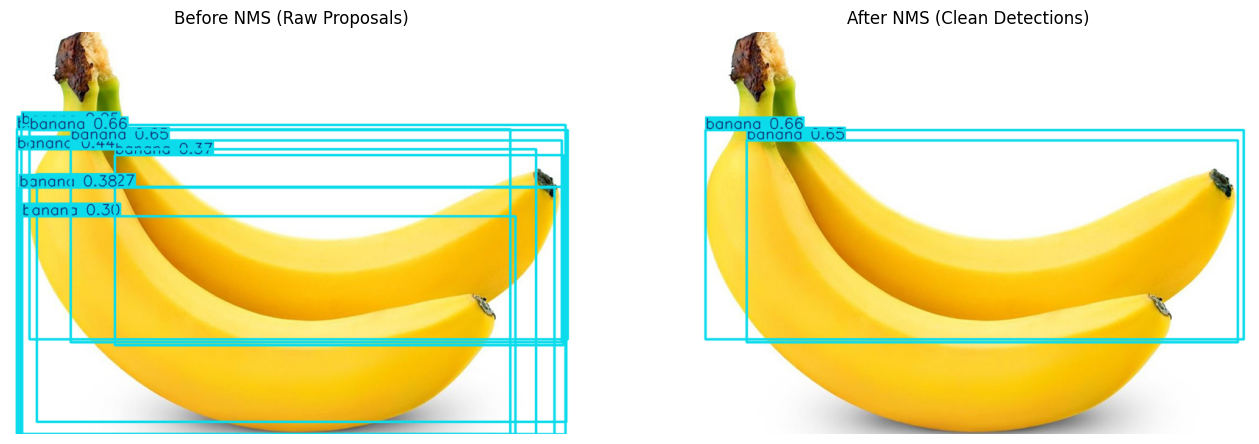

In [66]:
results = model_yolo.predict(random_test_img, conf=0.1, iou=0.9, verbose=False)[0] # High IOU = Noisy
img_before = results.plot()

# Now apply a strict NMS (Standard 0.5)
results_after = model_yolo.predict(random_test_img, conf=0.5, iou=0.9, verbose=False)[0]
img_after = results_after.plot()

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB))
ax[0].set_title("Before NMS (Raw Proposals)")
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB))
ax[1].set_title("After NMS (Clean Detections)")
ax[1].axis('off')

plt.savefig('nms_effect.png') # Save this for your GitHub!
plt.show()

### Evaluation and Comparison Table

In [57]:
start = time.time()
model_yolo.predict(random_img_path, verbose=False)
yolo_ft_time = (time.time() - start) * 1000

# Validation metrics from training results
metrics = model_yolo.val()
map50 = metrics.results_dict['metrics/mAP50(B)']
map50_95 = metrics.results_dict['metrics/mAP50-95(B)']
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']

print(f"\nFinal Test Set mAP@50: {map50:.4f}")
print(f"Final Test Set mAP@50-95: {map50_95:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2709.2±1219.2 MB/s, size: 121.3 KB)
val: Scanning /content/fruit_data/fruits/test.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6it/s 1.5s
                   all         60        117      0.886      0.799      0.899      0.657
                 apple         24         35       0.91      0.886      0.947      0.774
                banana         22         40      0.805      0.722      0.821       0.52
                orange         22         42      0.943      0.791      0.928      0.676
Speed: 3.8ms preprocess, 2.6ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val10

Final Test Set mAP@50: 0.8986
Final Test Set mAP@50-95: 0.6569


In [58]:
import torch
from torchvision.ops import box_iou
import pandas as pd

def evaluate_pretrained_on_test_set(model_type='yolo'):
    """
    Evaluates pre-trained models on the local fruit test set.
    Corrects for the different COCO indexing schemes between YOLO and Faster R-CNN.
    """
    # Mapping: COCO_ID -> Local_ID (Apple=0, Banana=1, Orange=2)
    if model_type == 'yolo':
        # COCO-80 Indices
        coco_mapping = {47: 0, 46: 1, 49: 2}
        model = YOLO('yolov8n.pt')
    else:
        # COCO-91 Indices (Used by Torchvision Faster R-CNN)
        coco_mapping = {53: 0, 52: 1, 55: 2}
        weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device)
        model.eval()

    test_path = '/content/fruit_data/fruits/test'
    xml_files = [f for f in os.listdir(test_path) if f.endswith('.xml')]

    tp, fp, fn = 0, 0, 0
    total_time = 0

    for xml_file in xml_files:
        img_path = os.path.join(test_path, xml_file.replace('.xml', '.jpg'))
        gt_boxes, gt_labels = parse_xml(os.path.join(test_path, xml_file))

        label_map = {'apple': 0, 'banana': 1, 'orange': 2}
        gt_ids = [label_map[l.lower()] for l in gt_labels]
        gt_boxes_t = torch.tensor(gt_boxes, dtype=torch.float)

        start = time.time()
        if model_type == 'yolo':
            results = model.predict(img_path, conf=0.5, verbose=False)[0]
            pred_boxes = results.boxes.xyxy.cpu()
            pred_ids_raw = results.boxes.cls.cpu().int().tolist()
        else:
            img = transforms.ToTensor()(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(img)[0]
            mask = out['scores'] > 0.5
            pred_boxes = out['boxes'][mask].cpu()
            pred_ids_raw = out['labels'][mask].cpu().int().tolist()

        total_time += (time.time() - start)
        pred_ids = [coco_mapping.get(idx, -1) for idx in pred_ids_raw]

        # Match Predictions to Ground Truth (IoU > 0.5)
        matched_gt = set()
        for i, p_box in enumerate(pred_boxes):
            if pred_ids[i] == -1: continue # Skip non-fruit

            if len(gt_boxes_t) > 0:
                ious = box_iou(p_box.unsqueeze(0), gt_boxes_t)
                best_iou, best_idx = ious.max(1)

                if best_iou > 0.5 and best_idx.item() not in matched_gt and pred_ids[i] == gt_ids[best_idx.item()]:
                    tp += 1
                    matched_gt.add(best_idx.item())
                else:
                    fp += 1
            else:
                fp += 1

        fn += (len(gt_ids) - len(matched_gt))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    avg_time_ms = (total_time / len(xml_files)) * 1000

    return avg_time_ms, precision, recall

# Run Evaluation
frcnn_pt_stats = evaluate_pretrained_on_test_set(model_type='faster')
yolo_pt_stats = evaluate_pretrained_on_test_set(model_type='yolo')

# Final Comparison Table Update
data = {
    "Model": ["Faster R-CNN (Pre-trained)", "YOLO (Pre-trained)", "YOLO (Fine-tuned)"],
    "Inference Time (ms)": [f"{frcnn_pt_stats[0]:.2f}", f"{yolo_pt_stats[0]:.2f}", f"{yolo_ft_time:.2f}"],
    "Precision": [f"{frcnn_pt_stats[1]:.3f}", f"{yolo_pt_stats[1]:.3f}", f"{precision:.3f}"],
    "Recall": [f"{frcnn_pt_stats[2]:.3f}", f"{yolo_pt_stats[2]:.3f}", f"{recall:.3f}"]
}

print(pd.DataFrame(data).to_markdown(index=False))

| Model                      |   Inference Time (ms) |   Precision |   Recall |
|:---------------------------|----------------------:|------------:|---------:|
| Faster R-CNN (Pre-trained) |                116.57 |       0.456 |    0.838 |
| YOLO (Pre-trained)         |                 15.14 |       0.676 |    0.624 |
| YOLO (Fine-tuned)          |                 13.97 |       0.886 |    0.799 |
